# Étape 4 — Analyse par classe et proximité sémantique

## 1. Contexte & Objectifs

Cette étape cherche à voir si les classes que le modèle confond le plus facilement sont aussi celles pour lesquelles la robustesse certifiée est la plus faible. Il s'agit d'une lecture exploratoire : les groupes sémantiques sont définis manuellement et les conclusions restent liées aux images effectivement vérifiées.

Pour chaque image du jeu de test :
1. Nous récupérons, pour chaque image, la classe concurrente la plus forte et la marge entre son logit et celui de la classe vraie.
2. Nous regroupons les paires en paires du même sous-domaine (animaux ou véhicules) et paires inter-domaines.
3. Nous déduisons un intervalle pour le seuil critique à partir des résultats SAT/UNSAT, sans donner une précision artificielle aux cas non encadrés.


## 2. Configuration & Dépendances

In [1]:
import re
import torch
from torch import nn
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'figure.titlesize': 17
})

def find_project_root(start: Path) -> Path:
    """Retrouve le dépôt, que le notebook soit lancé depuis sa racine ou son dossier notebooks/."""
    for candidate in (start, *start.parents):
        if (candidate / 'data').exists() and (candidate / 'benchmarks').exists():
            return candidate
    raise FileNotFoundError("Impossible de localiser la racine du projet.")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
RESULTS_CSV = PROJECT_ROOT / "data" / "experiments" / "csv" / "results.csv"
MODEL_PATH = PROJECT_ROOT / "benchmarks" / "models" / "eran" / "cifar_conv_small_pgd.pth"
DATASET_DIR = PROJECT_ROOT / "data" / "dataset" / "cifar10_test"

CIFAR10_CLASSES = [
    "avion", "automobile", "oiseau", "chat", "cerf",
    "chien", "grenouille", "cheval", "bateau", "camion"
]

# Le checkpoint ERAN a été entraîné avec cette normalisation CIFAR-10.
CIFAR10_MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1)
CIFAR10_STD = torch.tensor([0.2023, 0.1994, 0.2010]).view(1, 3, 1, 1)

for required_path in (RESULTS_CSV, MODEL_PATH, DATASET_DIR):
    if not required_path.exists():
        raise FileNotFoundError(f"Fichier ou dossier introuvable : {required_path}")

print(f"Racine du projet : {PROJECT_ROOT}")
print(f"Résultats analysés : {RESULTS_CSV.name}")

Racine du projet : /home/anasmefteh/crns/alpha-beta-crown-evaluation
Résultats analysés : results.csv


## 3. Extraction des Prédictions du Modèle et de la Seconde Classe

Le fichier de poids utilisé dans ce projet est sérialisé sous forme de liste. La cellule le remet donc dans l'ordre des paramètres du modèle avant l'inférence. La classe concurrente est la meilleure classe **différente de la vérité terrain** ; la marge peut ainsi être négative si l'image est déjà mal classée.

In [2]:
from PIL import Image

def make_conv_small():
    return nn.Sequential(
        nn.Conv2d(3, 16, 4, stride=2), nn.ReLU(),
        nn.Conv2d(16, 32, 4, stride=2), nn.ReLU(),
        nn.Flatten(), nn.Linear(32 * 6 * 6, 100), nn.ReLU(), nn.Linear(100, 10),
    )

def load_weights(model, model_path):
    try:
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=True)
    except TypeError:  # Compatibilité avec les versions de PyTorch antérieures à 2.0
        checkpoint = torch.load(model_path, map_location='cpu')

    if isinstance(checkpoint, dict):
        checkpoint = checkpoint.get('state_dict', checkpoint.get('state_dict_req', checkpoint))
    # Certains exports ERAN enveloppent la liste des poids dans une liste/tuple
    # à un seul élément. On retire cette enveloppe avant de l'associer au modèle.
    while (isinstance(checkpoint, (list, tuple)) and len(checkpoint) == 1
           and isinstance(checkpoint[0], (dict, list, tuple))):
        checkpoint = checkpoint[0]

    if isinstance(checkpoint, (list, tuple)):
        parameter_names = list(model.state_dict())
        if len(checkpoint) != len(parameter_names):
            raise ValueError(f"{len(checkpoint)} tenseurs trouvés, {len(parameter_names)} attendus.")
        checkpoint = dict(zip(parameter_names, checkpoint))

    if not isinstance(checkpoint, dict):
        raise TypeError(f"Format de checkpoint non pris en charge : {type(checkpoint)}")
    checkpoint = {key.removeprefix('module.'): value for key, value in checkpoint.items()}
    model.load_state_dict(checkpoint)

net = make_conv_small()
load_weights(net, MODEL_PATH)
net.eval()

def get_competing_class(image_id: int, true_label: int):
    img_path = DATASET_DIR / f"{image_id:05d}.png"
    img = Image.open(img_path).convert("RGB")
    arr = np.asarray(img, dtype=np.float32) / 255.0
    tensor = torch.from_numpy(np.transpose(arr, (2, 0, 1))).unsqueeze(0)
    tensor = (tensor - CIFAR10_MEAN) / CIFAR10_STD
    
    with torch.no_grad():
        logits = net(tensor).squeeze(0)
        top2 = torch.topk(logits, k=2).indices
        top1, runner_up = (int(class_id) for class_id in top2)
        competing_logits = logits.clone()
        competing_logits[true_label] = -torch.inf
        competing_class = int(competing_logits.argmax())
        
    # top-1 et runner-up sont les deux meilleures prédictions, donc distinctes.
    assert top1 != runner_up
    return top1, runner_up, competing_class, float(logits[true_label] - logits[competing_class])

# Chargement des résultats de la grille results.csv
df_res = pd.read_csv(RESULTS_CSV)

def parse_specification(path_str):
    m = re.search(r'(\d+)_label_(\d+)_eps_([\d.]+)\.vnnlib$', str(path_str))
    if m:
        return int(m.group(1)), int(m.group(2)), float(m.group(3)), round(float(m.group(3))*255)
    return None, None, None, None

df_res[['image_id', 'label', 'eps_float', 'eps_255']] = df_res['vnnlib_path'].apply(lambda x: pd.Series(parse_specification(x)))
if df_res[['image_id', 'label', 'eps_float']].isna().any().any():
    raise ValueError("Au moins un chemin VNN-LIB ne suit pas le format attendu.")

# Les résultats SAT et UNSAT encadrent le seuil critique lorsqu'ils sont tous les deux présents.
img_records = []
for img_id, group in df_res.groupby('image_id'):
    img_id = int(img_id)
    label = int(group['label'].iloc[0])
    unsat_eps = group[group['result'] == 'UNSAT']['eps_255'].tolist()
    sat_eps = group[group['result'] == 'SAT']['eps_255'].tolist()
    
    lower_bound = max(unsat_eps) if unsat_eps else np.nan
    upper_bound = min(sat_eps) if sat_eps else np.nan
    if unsat_eps and sat_eps:
        eps_estimate, interval_status = (lower_bound + upper_bound) / 2, 'encadré'
    elif unsat_eps:
        eps_estimate, interval_status = lower_bound, 'borne inférieure seule'
    else:
        eps_estimate, interval_status = upper_bound, 'borne supérieure seule'
    
    top1, runner_up, competing_class, margin = get_competing_class(img_id, label)
    
    img_records.append({
        'image_id': img_id,
        'true_label': label,
        'true_name': CIFAR10_CLASSES[label],
        'top1_pred': top1,
        'top1_name': CIFAR10_CLASSES[top1],
        'runner_up_pred': runner_up,
        'runner_up_name': CIFAR10_CLASSES[runner_up],
        'competing_pred': competing_class,
        'competing_name': CIFAR10_CLASSES[competing_class],
        'margin': margin,
        'eps_star_255': eps_estimate,
        'borne_inferieure_255': lower_bound,
        'borne_superieure_255': upper_bound,
        'statut_intervalle': interval_status
    })

df_pairs = pd.DataFrame(img_records)
df_pairs.head(15)

,image_id,true_label,true_name,top1_pred,top1_name,runner_up_pred,runner_up_name,competing_pred,competing_name,margin,eps_star_255,borne_inferieure_255,borne_superieure_255,statut_intervalle
0,0,3,chat,3,chat,5,chien,5,chien,2.487235,1.0,NaN,1.0,borne supérieure seule
1,400,9,camion,9,camion,1,automobile,1,automobile,6.614324,1.0,NaN,1.0,borne supérieure seule
2,800,7,cheval,7,cheval,4,cerf,4,cerf,11.808087,1.0,NaN,1.0,borne supérieure seule
3,1189,0,avion,0,avion,2,oiseau,2,oiseau,2.310817,3.0,2.0,4.0,encadré
4,1200,8,bateau,8,bateau,0,avion,0,avion,5.921483,1.0,NaN,1.0,borne supérieure seule
5,1600,8,bateau,8,bateau,6,grenouille,6,grenouille,0.896197,1.0,NaN,1.0,borne supérieure seule
6,2000,1,automobile,6,grenouille,1,automobile,6,grenouille,-0.951692,1.0,NaN,1.0,borne supérieure seule
7,2400,0,avion,0,avion,4,cerf,4,cerf,5.860667,8.0,8.0,NaN,borne inférieure seule
8,2800,4,cerf,4,cerf,6,grenouille,6,grenouille,0.032232,1.0,NaN,1.0,borne supérieure seule
9,3200,5,chien,7,cheval,5,chien,7,cheval,-2.579261,1.0,NaN,1.0,borne supérieure seule


## 4. Classification des Paires Sémantiques (Proches vs Éloignées)

Le découpage est volontairement simple et reproductible : les paires animal–animal et véhicule–véhicule sont dites « même sous-domaine » ; les paires animal–véhicule sont dites « inter-domaines ». Cela ne mesure pas une distance sémantique universelle, mais fournit un premier point de comparaison lisible.

In [3]:
VEHICLES = {0, 1, 8, 9}  # avion, automobile, bateau, camion
ANIMALS = {2, 3, 4, 5, 6, 7}  # oiseau, chat, cerf, chien, grenouille, cheval

def classify_pair_proximity(row):
    c1, c2 = row['true_label'], row['competing_pred']
    pair_str = f"{row['true_name']} → {row['competing_name']}"
    
    if (c1 in VEHICLES and c2 in VEHICLES) or (c1 in ANIMALS and c2 in ANIMALS):
        proximity = "Paires Proches (Même sous-domaine)"
    else:
        proximity = "Paires Éloignées (Inter-domaines)"
        
    return pd.Series([pair_str, proximity])

df_pairs[['pair_label', 'proximite_semantique']] = df_pairs.apply(classify_pair_proximity, axis=1)

print("Répartition des images :")
display(df_pairs['proximite_semantique'].value_counts().rename('nombre').to_frame())
print("\nQualité de l'encadrement du seuil :")
display(df_pairs['statut_intervalle'].value_counts().rename('nombre').to_frame())

df_pairs[['image_id', 'pair_label', 'margin', 'eps_star_255', 'statut_intervalle',
          'proximite_semantique']].sort_values('image_id').head(20)

Répartition des images :


,nombre
proximite_semantique,
Paires Proches (Même sous-domaine),19
Paires Éloignées (Inter-domaines),6



Qualité de l'encadrement du seuil :


,nombre
statut_intervalle,
borne supérieure seule,19
encadré,4
borne inférieure seule,2


,image_id,pair_label,margin,eps_star_255,statut_intervalle,proximite_semantique
0,0,chat → chien,2.487235,1.0,borne supérieure seule,Paires Proches (Même sous-domaine)
1,400,camion → automobile,6.614324,1.0,borne supérieure seule,Paires Proches (Même sous-domaine)
2,800,cheval → cerf,11.808087,1.0,borne supérieure seule,Paires Proches (Même sous-domaine)
3,1189,avion → oiseau,2.310817,3.0,encadré,Paires Éloignées (Inter-domaines)
4,1200,bateau → avion,5.921483,1.0,borne supérieure seule,Paires Proches (Même sous-domaine)
5,1600,bateau → grenouille,0.896197,1.0,borne supérieure seule,Paires Éloignées (Inter-domaines)
6,2000,automobile → grenouille,-0.951692,1.0,borne supérieure seule,Paires Éloignées (Inter-domaines)
7,2400,avion → cerf,5.860667,8.0,borne inférieure seule,Paires Éloignées (Inter-domaines)
8,2800,cerf → grenouille,0.032232,1.0,borne supérieure seule,Paires Proches (Même sous-domaine)
9,3200,chien → cheval,-2.579261,1.0,borne supérieure seule,Paires Proches (Même sous-domaine)


## 5. Lecture des résultats

Le point central de chaque image est le milieu de son intervalle lorsqu'il est encadré. Pour les autres images, il correspond à la seule borne disponible ; elles sont donc représentées avec un marqueur creux et ne doivent pas être interprétées comme une mesure exacte.

,nombre,mediane,moyenne,minimum,maximum
proximite_semantique,,,,,
Paires Proches (Même sous-domaine),19,1.0,1.32,1.0,6.0
Paires Éloignées (Inter-domaines),6,2.0,3.67,1.0,8.0


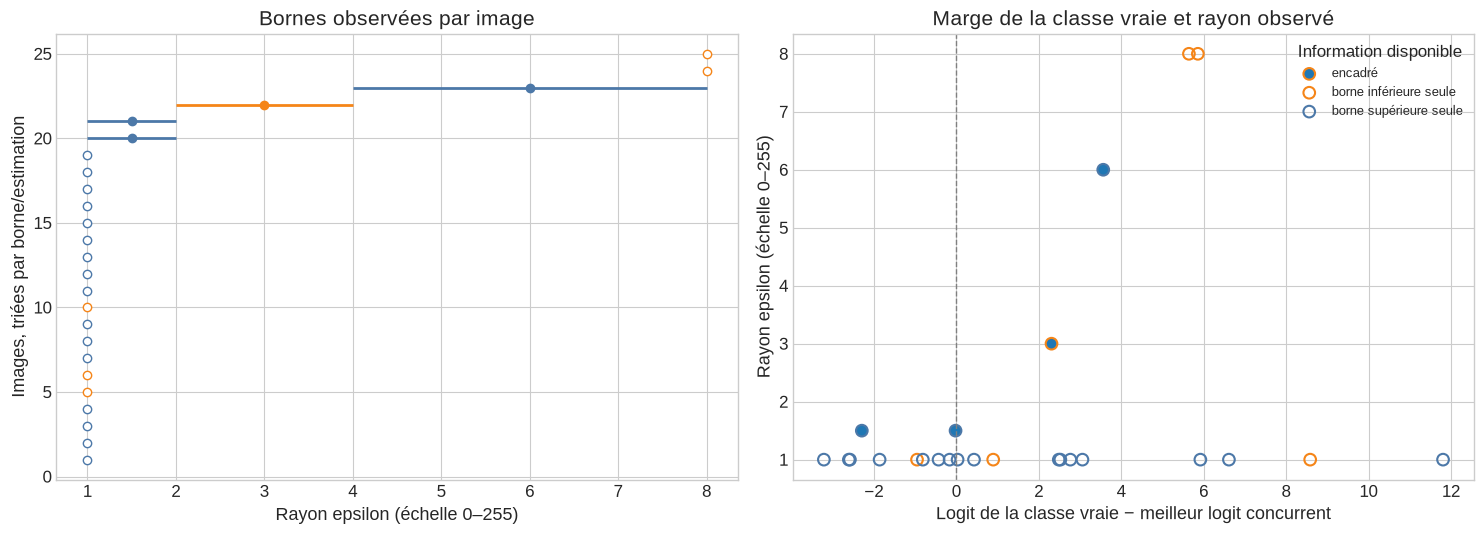

In [4]:
display(df_pairs.groupby('proximite_semantique')['eps_star_255']
        .agg(nombre='count', mediane='median', moyenne='mean', minimum='min', maximum='max')
        .round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
colors = {'Paires Proches (Même sous-domaine)': '#4c78a8',
          'Paires Éloignées (Inter-domaines)': '#f58518'}

# Chaque segment représente l'intervalle obtenu avec la grille de vérification.
for index, row in df_pairs.sort_values('eps_star_255').reset_index(drop=True).iterrows():
    color = colors[row['proximite_semantique']]
    y = index + 1
    if pd.notna(row['borne_inferieure_255']) and pd.notna(row['borne_superieure_255']):
        axes[0].hlines(y, row['borne_inferieure_255'], row['borne_superieure_255'], color=color, lw=2)
    axes[0].plot(row['eps_star_255'], y, 'o', color=color, ms=6,
                 markerfacecolor=color if row['statut_intervalle'] == 'encadré' else 'white')
axes[0].set_title("Bornes observées par image")
axes[0].set_xlabel("Rayon epsilon (échelle 0–255)")
axes[0].set_ylabel("Images, triées par borne/estimation")

for status, marker, facecolor in [('encadré', 'o', None), ('borne inférieure seule', 'o', 'none'),
                                  ('borne supérieure seule', 'o', 'none')]:
    subset = df_pairs[df_pairs['statut_intervalle'] == status]
    axes[1].scatter(subset['margin'], subset['eps_star_255'], s=70, marker=marker,
                    facecolors=facecolor, edgecolors=[colors[x] for x in subset['proximite_semantique']],
                    label=status, linewidths=1.5)
axes[1].axvline(0, color='0.5', lw=1, ls='--')
axes[1].set_title("Marge de la classe vraie et rayon observé")
axes[1].set_xlabel("Logit de la classe vraie − meilleur logit concurrent")
axes[1].set_ylabel("Rayon epsilon (échelle 0–255)")
axes[1].legend(title="Information disponible", fontsize=9)

plt.tight_layout()
plt.show()

## 6. Ce que l'on peut conclure

- Les tableaux et les graphiques décrivent uniquement les images présentes dans `results.csv`. Ils ne suffisent pas, à eux seuls, à généraliser à l'ensemble de CIFAR-10.
- Un segment plein correspond à un seuil encadré entre un résultat UNSAT et un résultat SAT. Un point creux indique qu'une seule borne a été observée : il est utile pour situer le cas, mais ne donne pas un seuil critique exact.
- Si un écart apparaît entre les deux groupes, il constitue une piste à vérifier sur davantage d'images et avec une grille d'epsilon plus fine. Il faut en particulier éviter d'attribuer cet écart à la seule proximité sémantique sans contrôler la difficulté propre des images.

Cette lecture est donc une étape de diagnostic : elle permet d'identifier les confusions et les cas à examiner, plutôt que d'établir une règle générale sur les classes.
